In [4]:
# =====================================
# ORANGE VS GRAPEFRUIT CLASSIFICATION
# =====================================

# 1. Import Library
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Saving citrus.csv to citrus.csv


In [5]:
df = pd.read_csv('/content/citrus.csv')
df.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [13]:
print(df.columns)

Index(['name', 'diameter', 'weight', 'red', 'green', 'blue'], dtype='object')


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


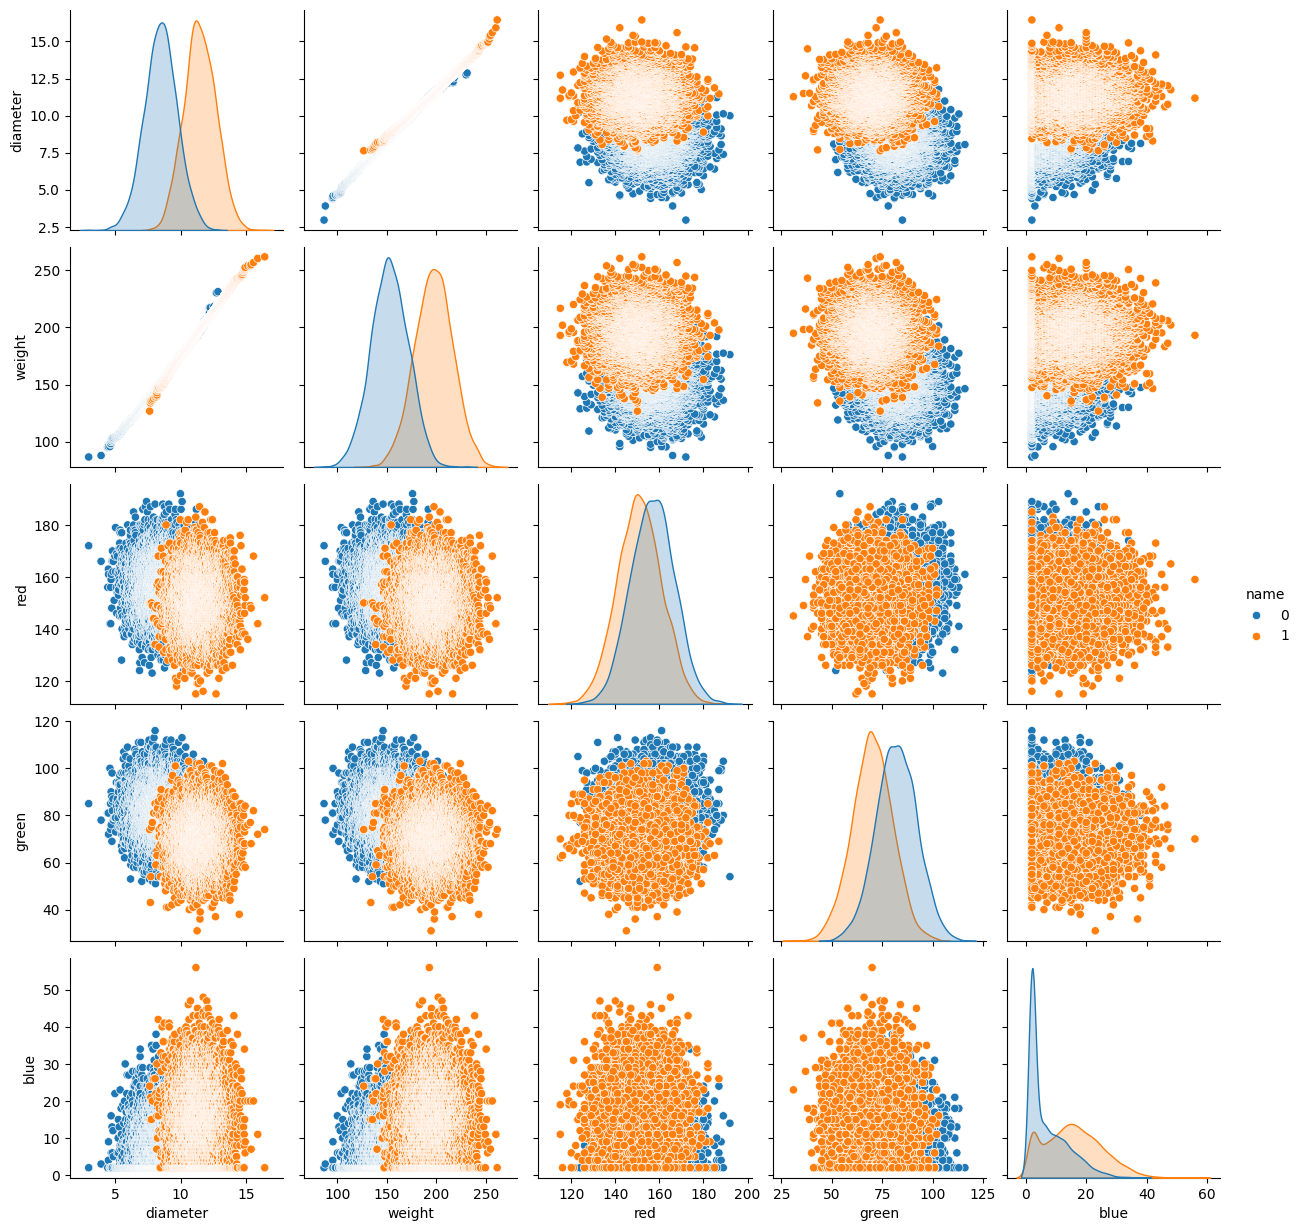

<Axes: >

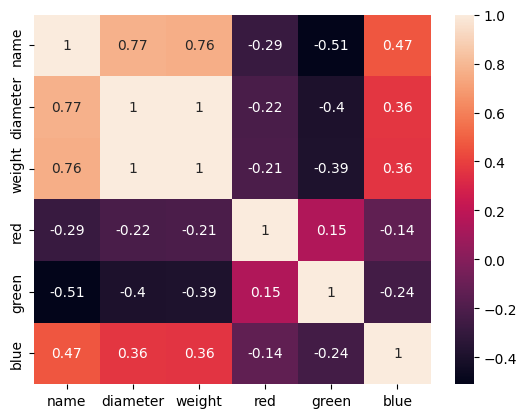

In [14]:
sns.pairplot(df, hue='name')
plt.show()

sns.heatmap(df.corr(), annot=True)

In [27]:
import pandas as pd # Ensure pandas is imported
# Reload the dataframe to ensure 'name' column is string type
df = pd.read_csv('/content/citrus.csv')

# Encode label, strip whitespace and convert to lowercase before mapping
df['name'] = df['name'].str.strip().str.lower().map({'orange':0, 'grapefruit':1})

X = df.drop('name', axis=1)
y = df['name']

# Remove rows with NaN values in y (which might occur if there are other fruit names not in the map)
not_nan_mask = y.notna()
X_cleaned = X[not_nan_mask]
y_cleaned = y[not_nan_mask]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.2, random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

Naive Bayes

In [36]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

SVM(Support Vector Machine)

In [37]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

SVC()

In [38]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_dt = dt.predict(X_test)
y_nb = nb.predict(X_test)
y_svm = svm.predict(X_test_scaled)

# Accuracy
print("DT:", accuracy_score(y_test, y_dt))
print("NB:", accuracy_score(y_test, y_nb))
print("SVM:", accuracy_score(y_test, y_svm))

# Report
print(classification_report(y_test, y_dt))
print(classification_report(y_test, y_nb))
print(classification_report(y_test, y_svm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


DT: 0.494
NB: 0.92
SVM: 0.937
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1012
           1       0.49      1.00      0.66       988

    accuracy                           0.49      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.24      0.49      0.33      2000

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1012
           1       0.91      0.93      0.92       988

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1012
           1       0.93      0.95      0.94       988

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Soal Nomer 2

In [40]:
# 1. Import Library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 2. Load Data
df = pd.read_csv('citrus.csv')

# 3. Preprocessing
# Kolom yang benar adalah 'name', bukan 'fruit'
df['name'] = df['name'].str.strip().str.lower().map({'orange': 0, 'grapefruit': 1})

X = df.drop('name', axis=1)
y = df['name']

# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling (untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Training
dt = DecisionTreeClassifier()
nb = GaussianNB()
svm = SVC()

dt.fit(X_train, y_train)
nb.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)

# 7. Prediction
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_svm = svm.predict(X_test_scaled)

# 8. Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

print("\n=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("\n=== SVM ===")
print(classification_report(y_test, y_pred_svm))

Decision Tree Accuracy: 0.9445
Naive Bayes Accuracy: 0.92
SVM Accuracy: 0.937

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1012
           1       0.94      0.95      0.94       988

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000


=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1012
           1       0.91      0.93      0.92       988

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000


=== SVM ===
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1012
           1       0.93      0.95      0.94       988

    accuracy                           0.94    

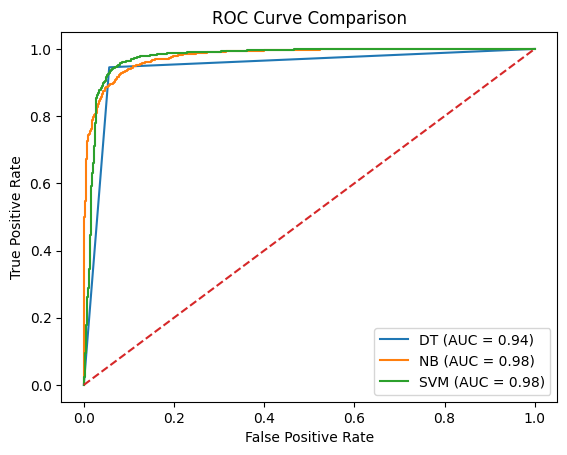

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilitas
y_prob_dt = dt.predict_proba(X_test)[:,1]
y_prob_nb = nb.predict_proba(X_test)[:,1]
y_prob_svm = svm.decision_function(X_test_scaled)

# ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

# AUC
auc_dt = auc(fpr_dt, tpr_dt)
auc_nb = auc(fpr_nb, tpr_nb)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot
plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {auc_dt:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'NB (AUC = {auc_nb:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()